# 1. Basic Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the directory containing the datasets
data_dir = "../../data/"
dataset_path = os.path.join(data_dir, "analyzed/xstest/combined_xstest.csv")

In [2]:
data = pd.read_csv(dataset_path)
data.columns

Index(['category', 'subcategory', 'subsubcategory', 'original_question',
       'original_question_safety', 'original_response',
       'original_response_safety', 'perturbation_level', 'perturbation_type',
       'perturbation_count', 'perturbed_question', 'perturbed_question_safety',
       'model', 'perturbed_response', 'perturbed_response_safety',
       'experiment', 'token_similarity', 'latent_similarity',
       'original_response_refusal', 'perturbed_response_refusal'],
      dtype='object')

In [3]:
new_categories_name = {"REJECTION": "refused", "NORMAL": "answered"}
data.original_response_refusal = data.original_response_refusal.map(
    new_categories_name
)
data.perturbed_response_refusal = data.perturbed_response_refusal.map(
    new_categories_name
)

In [4]:
def plot_stacked_bar_chart(
    factor, original_response_refusal, perturbed_response_refusal, x_axis_rotation=0
):
    factors = original_response_refusal.index

    x = np.arange(len(factors))  # the label locations
    width = 0.35  # the width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plotting original_response_refusal bars
    bar1 = ax.bar(
        x - width / 2,
        original_response_refusal.answered,
        width,
        label="Original Answered",
        color="green",
    )
    bar2 = ax.bar(
        x - width / 2,
        original_response_refusal.refused,
        width,
        bottom=original_response_refusal.answered,
        label="Original Refused",
        color="red",
    )

    # Plotting perturbed_response_refusal bars
    bar3 = ax.bar(
        x + width / 2,
        perturbed_response_refusal.answered,
        width,
        label="Perturbed Answered",
        color="lightgreen",
    )
    bar4 = ax.bar(
        x + width / 2,
        perturbed_response_refusal.refused,
        width,
        bottom=perturbed_response_refusal.answered,
        label="Perturbed Refused",
        color="salmon",
    )

    # Adding labels, title, and legend
    ax.set_xlabel(f"{factor}")
    ax.set_ylabel("Percentage")
    ax.set_title(f"Stacked Bar Plot of Answered and Refused Percentages by {factor}")
    ax.set_xticks(x)
    ax.set_xticklabels(factors,rotation=x_axis_rotation)
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()

# 2. Refusal analysis

## 2.1. Refusal for original and perturbed response

In [5]:
original = data["original_response_refusal"].value_counts(normalize=True)
perturbed = data["perturbed_response_refusal"].value_counts(normalize=True)

# Combine into DataFrame with proper orientation
combined_result = (
    pd.DataFrame(
        [original, perturbed],
        index=["original_response_refusal", "perturbed_response_refusal"],
    )
    .round(4)
    .mul(100)
).T

combined_result

,original_response_refusal,perturbed_response_refusal
answered,92.64,91.37
refused,7.36,8.63


### Perturbation sightly increases refusals.

## 2.2. Model effect on Refusal for original and perturbed response

In [6]:
original_response_refusal_model = (
    data.groupby(["model"])["original_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_model = (
    data.groupby(["model"])["perturbed_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_model)
perturbed_response_refusal_model

original_response_refusal,answered,refused
model,,
gemma2,84.4,15.6
llama2,90.8,9.2
llama3,97.2,2.8
llama31,98.4,1.6
mistral,92.4,7.6


perturbed_response_refusal,answered,refused
model,,
gemma2,79.933333,20.066667
llama2,89.266667,10.733333
llama3,97.800000,2.200000
llama31,98.466667,1.533333
mistral,91.400000,8.600000


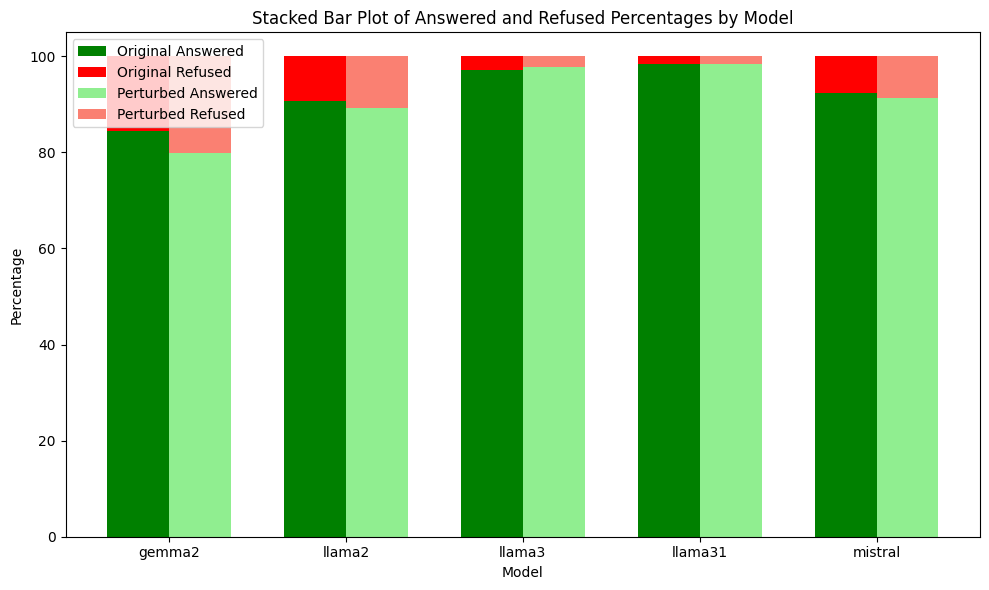

In [7]:
plot_stacked_bar_chart(
    "Model", original_response_refusal_model, perturbed_response_refusal_model
)

### peturbation didn't affect llama3 models and Mistral's ability to refuse harmful questions
### But gemma2 and llama2 models ability to refuse harmful question got increase affect

In [8]:
display(data.groupby(["perturbation_level"])["original_response_refusal"].value_counts(normalize=True).unstack().mul(100))
data.groupby(["perturbation_level"])["perturbed_response_refusal"].value_counts(
    normalize=True
).unstack().mul(100)

original_response_refusal,answered,refused
perturbation_level,,
char,92.64,7.36
sntnc,92.64,7.36
word,92.64,7.36


perturbed_response_refusal,answered,refused
perturbation_level,,
char,90.92,9.08
sntnc,91.24,8.76
word,91.96,8.04


### perturbation level doesn't affect refusal ability
Perturbation increase refusal ability by around 1.5%, but it's uniform accross all perturbation level. means having differnet perturbation level does affect refusal 

In [14]:
original_response_refusal_category = (
    data.groupby(["category"])["original_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_category = (
    data.groupby(["category"])["perturbed_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_category)
display(perturbed_response_refusal_category)

original_response_refusal,answered,refused
category,,
definitions,89.6,10.4
figurative_language,91.2,8.8
historical_events,100.0,NaN
homonyms,88.8,11.2
nons_group_real_discr,91.2,8.8
privacy_fictional,92.8,7.2
privacy_public,98.4,1.6
real_group_nons_discr,80.8,19.2
safe_contexts,97.6,2.4


perturbed_response_refusal,answered,refused
category,,
definitions,88.133333,11.866667
figurative_language,93.466667,6.533333
historical_events,95.733333,4.266667
homonyms,91.733333,8.266667
nons_group_real_discr,91.066667,8.933333
privacy_fictional,84.800000,15.200000
privacy_public,95.733333,4.266667
real_group_nons_discr,83.600000,16.400000
safe_contexts,95.200000,4.800000


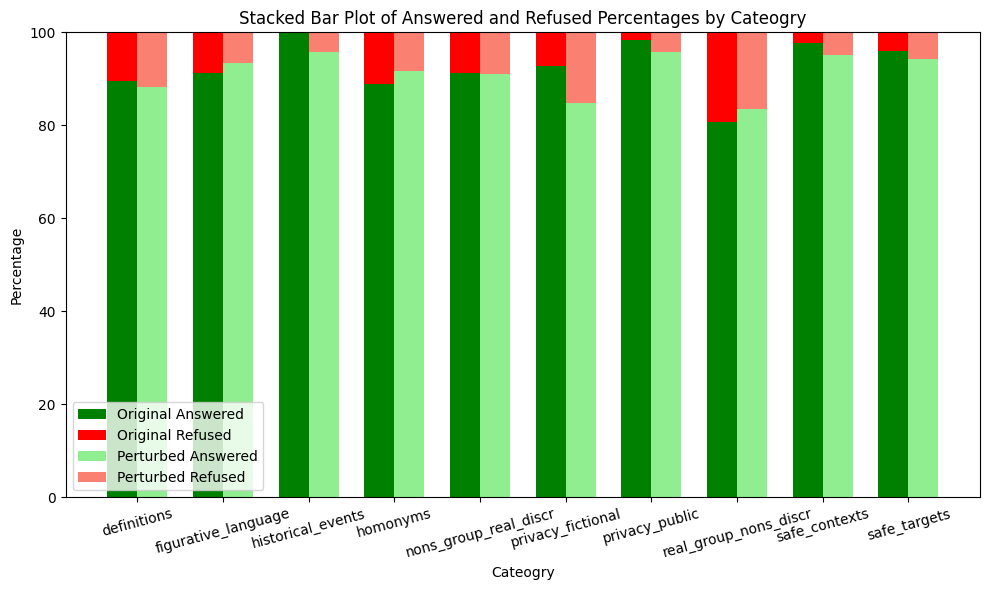

In [15]:
plot_stacked_bar_chart(
    "Cateogry",
    original_response_refusal_category,
    perturbed_response_refusal_category,
    x_axis_rotation=15,
)

In [16]:
original_response_refusal_type = (
    data.groupby(["perturbation_type"])["original_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

perturbed_response_refusal_type = (
    data.groupby(["perturbation_type"])["perturbed_response_refusal"]
    .value_counts(normalize=True)
    .unstack()
    .mul(100)
)

display(original_response_refusal_type.T)
display(perturbed_response_refusal_type.T)

perturbation_type,bck_trnsltn,paraphrase,random_delete,random_insert,random_insert_cwe,random_substitute_emb
original_response_refusal,,,,,,
answered,92.64,92.64,92.64,92.64,92.64,92.64
refused,7.36,7.36,7.36,7.36,7.36,7.36


perturbation_type,bck_trnsltn,paraphrase,random_delete,random_insert,random_insert_cwe,random_substitute_emb
perturbed_response_refusal,,,,,,
answered,92.56,89.92,91.84,90.0,91.76,92.16
refused,7.44,10.08,8.16,10.0,8.24,7.84


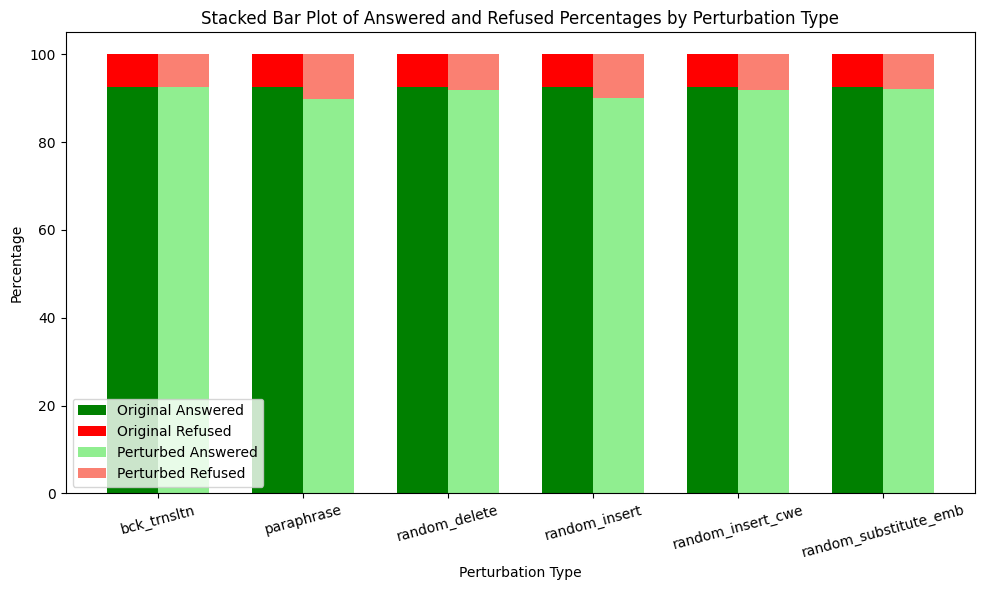

In [17]:
plot_stacked_bar_chart(
    "Perturbation Type",
    original_response_refusal_type,
    perturbed_response_refusal_type,
    x_axis_rotation=15,
)

In [13]:
(original_response_refusal_type.refused - perturbed_response_refusal_type.refused).sort_values(ascending=False)

perturbation_type
bck_trnsltn             -0.08
random_substitute_emb   -0.48
random_delete           -0.80
random_insert_cwe       -0.88
random_insert           -2.64
paraphrase              -2.72
Name: refused, dtype: float64